# Elite Fleet Dispatch — Qwen2.5-7B Fine-Tuning (Unsloth)
**Project:** Ultra-Elite Chauffeur AI Dispatcher  
**Model:** `Qwen/Qwen2.5-7B-Instruct` + LoRA via Unsloth  
**Goal:** Fine-tune on proprietary dispatch scenarios → maximize vehicle-selection decision accuracy  
**Tracking:** Weights & Biases (training) + LangSmith (inference tracing)

---

### 📋 Notebook Structure
| Section | Description |
|---|---|
| 1 | Environment Setup |
| 2 | Credentials (W&B + LangSmith) |
| 3 | Load Model & Configure LoRA |
| 4 | Load & Prepare Dataset |
| 5 | Baseline Evaluation (pre fine-tuning) |
| 6 | Training |
| 7 | Fine-Tuned Evaluation & Comparison |
| 8 | Interactive Demo (Gradio) |
| 9 | Save & Push to Hugging Face Hub |
| 10 | Deploy Public Web App (HF Spaces) |

---
## Section 1 — Environment Setup

In [ ]:
%%capture
!pip install -U "unsloth[colab-new]"
!pip install wandb langsmith bert-score -qU

In [ ]:
import os
import re
import warnings
import torch
import wandb
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix
from unsloth import FastLanguageModel, is_bfloat16_supported
from trl import SFTTrainer
from transformers import TrainingArguments
from bert_score import scorer as bert_scorer_lib
from langsmith import traceable

warnings.filterwarnings("ignore")
print(f"PyTorch  : {torch.__version__}")
print(f"CUDA     : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU      : {torch.cuda.get_device_name(0)}")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
PyTorch  : 2.10.0+cu128
CUDA     : True
GPU      : Tesla T4


---
## Section 2 — Credentials (W&B + LangSmith)
> **Security:** Store API keys in Colab Secrets

In [ ]:
H_# ── Weights & Biases ──────────────────────────────────────────────────────────
wandb.login()

# ── LangSmith (inference tracing) ────────────────────────────────────────────
os.environ.setdefault("LANGCHAIN_TRACING_V2", "true")
os.environ.setdefault("LANGCHAIN_ENDPOINT",   "https://api.smith.langchain.com")
os.environ.setdefault("LANGCHAIN_API_KEY",    os.getenv("LANGSMITH_API_KEY",() )
os.environ.setdefault("LANGCHAIN_PROJECT",    "elite-fleet-inference")

print("Credentials configured.")
print(f"LangSmith project : {os.environ['LANGCHAIN_PROJECT']}")

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /teamspace/studios/this_studio/.netrc.
wandb: Currently logged in as: rodynamohamed610 (rodynamohamed610-qu) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Credentials configured.
LangSmith project : elite-fleet-inference


---
## Section 3 — Load Model & Configure LoRA

### LoRA Improvements vs Original Notebook

| Hyperparameter | Original | **Improved** | Why it helps |
|---|---|---|---|
| `r` (rank) | 16 | **32** | More trainable parameters → better task fit |
| `lora_alpha` | 16 | **64** | alpha/r = 2 is the proven stable ratio |
| `target_modules` | 4 (attn only) | **7 (attn + MLP)** | MLP layers carry most task-specific knowledge |
| `use_rslora` | False | **True** | Rank-stabilised scaling → more stable training |

In [ ]:
# ── 3a. Model config ──────────────────────────────────────────────────────────
MAX_SEQ_LENGTH = 2048
DTYPE          = None
LOAD_IN_4BIT   = True       # QLoRA — saves ~50% VRAM

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name     = "Qwen/Qwen2.5-7B-Instruct",
    max_seq_length = MAX_SEQ_LENGTH,
    dtype          = DTYPE,
    load_in_4bit   = LOAD_IN_4BIT,
)
print("Base model loaded.")

==((====))==  Unsloth 2026.2.1: Fast Qwen2 patching. Transformers: 4.57.6.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Base model loaded.


In [ ]:
# ── 3b. LoRA adapters ─────────────────────────────────────────────────────────
model = FastLanguageModel.get_peft_model(
    model,
    r              = 32,
    lora_alpha     = 64,
    target_modules = [
        "q_proj", "k_proj", "v_proj", "o_proj",   # attention layers
        "gate_proj", "up_proj", "down_proj",       # MLP / feedforward layers
    ],
    lora_dropout              = 0,        # 0 is optimal for QLoRA
    bias                      = "none",
    use_gradient_checkpointing = "unsloth",
    use_rslora                = True,     # rank-stabilized scaling
    random_state              = 3407,
    loftq_config              = None,
)
model.print_trainable_parameters()

Unsloth 2026.2.1 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


trainable params: 80,740,352 || all params: 7,696,356,864 || trainable%: 1.0491


---
## Section 4 — Load & Prepare Dataset

In [ ]:
# ── 4a. Load & split (90% train, 10% test) ────────────────────────────────────
raw_dataset   = load_dataset("json", data_files="london_cab_finetune.jsonl", split="train")
dataset_split = raw_dataset.train_test_split(test_size=0.1, seed=3407)
train_dataset = dataset_split["train"]
test_dataset  = dataset_split["test"]

print(f"Train samples : {len(train_dataset)}")
print(f"Test  samples : {len(test_dataset)}")

Train samples : 1800
Test  samples : 200


In [ ]:
# ── 4b. System prompt ─────────────────────────────────────────────────────────
SYSTEM_PROMPT = (
    "You are the Head of Dispatch for an Ultra-Elite Chauffeur Service. "
    "Review the mission constraints (Client Tier, Pax, Distance) and the available fleet. "
    "Select the optimal vehicle to maximize client satisfaction and safety. "
    "Explain your reasoning precisely."
)

# ── 4c. Format prompts into Qwen ChatML template ──────────────────────────────
def formatting_prompts_func(examples):
    texts = []
    for conv in examples["messages"]:
        user      = conv[1]["content"]
        assistant = conv[2]["content"]
        text = (
            f"<|im_start|>system\n{SYSTEM_PROMPT}<|im_end|>\n"
            f"<|im_start|>user\n{user}<|im_end|>\n"
            f"<|im_start|>assistant\n{assistant}<|im_end|>"
        )
        texts.append(text)
    return {"text": texts}

train_dataset = train_dataset.map(formatting_prompts_func, batched=True)
test_dataset  = test_dataset.map(formatting_prompts_func, batched=True)

print("Datasets formatted.")
print("\nSample prompt preview:")
print(train_dataset[0]["text"][:400], "...")

Datasets formatted.

Sample prompt preview:
<|im_start|>system
You are the Head of Dispatch for an Ultra-Elite Chauffeur Service. Review the mission constraints (Client Tier, Pax, Distance) and the available fleet. Select the optimal vehicle to maximize client satisfaction and safety. Explain your reasoning precisely.<|im_end|>
<|im_start|>user
MISSION BRIEF:
- Type: Night Out
- Client Tier: Standard Elite
- Passengers: 2
- Distance: 33.4 m ...


---
## Section 5 — Baseline Evaluation (Pre Fine-Tuning)

We evaluate the **base model before any training** so we can quantify the exact improvement fine-tuning delivers.  
This uses the same test set and helpers used in Section 7, making the comparison perfectly fair.

> LangSmith traces every `dispatch_vehicle()` call automatically via `@traceable`.

In [ ]:
# ── Shared helpers ──

def extract_option(text: str) -> str:
    """Extracts 'Option X' from model output. Returns 'Unknown' if not found."""
    match = re.search(r"Option\s*\d+", text, re.IGNORECASE)
    return match.group(0).title() if match else "Unknown"

def safety_judge(prediction: str, mission_brief: str) -> int:
    """Returns 1 (pass) if no under-maintenance vehicle was selected, else 0 (fail)."""
    selected = extract_option(prediction)
    for line in mission_brief.split("\n"):
        if "Maint: YES" in line and selected in line:
            return 0
    return 1

def run_evaluation(dataset, label="Model"):
    """
    Runs the full evaluation loop on a given dataset.
    Returns y_true, y_pred, safety_scores, all_true_texts, all_pred_texts.
    """
    print(f"\nEvaluating: {label} on {len(dataset)} samples...\n")
    y_true, y_pred       = [], []
    all_true_texts       = []
    all_pred_texts       = []
    safety_scores        = []

    for i, sample in enumerate(dataset):
        msgs          = sample["messages"]
        true_output   = msgs[2]["content"]
        mission_input = msgs[1]["content"]

        prediction = dispatch_vehicle(mission_input)

        y_true.append(extract_option(true_output))
        y_pred.append(extract_option(prediction))
        all_true_texts.append(true_output)
        all_pred_texts.append(prediction)
        safety_scores.append(safety_judge(prediction, mission_input))



    acc    = sum(t == p for t, p in zip(y_true, y_pred)) / len(y_true) * 100
    safety = sum(safety_scores) / len(safety_scores) * 100
    print(f"\n  Accuracy    : {acc:.1f}%")
    print(f"  Safety Rate : {safety:.1f}%")
    return y_true, y_pred, safety_scores, all_true_texts, all_pred_texts

In [ ]:
# ── 5a. Set model to inference mode ───────────────────────────────────────────
FastLanguageModel.for_inference(model)

# ── 5b. dispatch_vehicle — decorated with @traceable for LangSmith logging ────
@traceable(name="dispatch_vehicle_baseline", run_type="llm")
def dispatch_vehicle(mission_brief: str) -> str:
    """
    Runs inference and returns the assistant reply.
    Every call is automatically logged to LangSmith:
      - Input  : the full mission brief
      - Output : the AI dispatcher decision
      - Latency, errors, timestamps
    Check: smith.langchain.com → Project: elite-fleet-inference
    """
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user",   "content": mission_brief},
    ]
    inputs = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt = True,
        return_tensors        = "pt",
        return_attention_mask = True,
    ).to("cuda")

    outputs = model.generate(
        inputs,
        max_new_tokens = 128,
        temperature    = 0.1,   # low temp for deterministic dispatch decisions
        do_sample      = True,
        use_cache      = True,
    )
    response = tokenizer.batch_decode(outputs)[0]
    return response.split("<|im_start|>assistant")[-1].replace("<|im_end|>", "").strip()

In [ ]:
# ── 5c. Run baseline evaluation ───────────────────────────────────────────────
(base_y_true, base_y_pred,
 base_safety,  base_true_texts,
 base_pred_texts) = run_evaluation(test_dataset, label="Base Model (no fine-tuning)")

base_accuracy = sum(t == p for t, p in zip(base_y_true, base_y_pred)) / len(base_y_true) * 100
base_safety_rate = sum(base_safety) / len(base_safety) * 100

print("\nBaseline evaluation complete. Results saved for comparison in Section 7.")


Evaluating: Base Model (no fine-tuning) on 200 samples...



The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.



  Accuracy    : 25.0%
  Safety Rate : 99.0%

Baseline evaluation complete. Results saved for comparison in Section 7.


---
## Section 6 — Training

### Training Improvements vs Original Notebook

| Setting | Original | **Improved** | Reason |
|---|---|---|---|
| `max_steps` | 60 | removed | Too few steps → severe underfitting |
| `num_train_epochs` | — | **3** | Full dataset passes ensure convergence |
| `learning_rate` | 2e-4 | **1e-4** | Lower LR + RSLoRA → more stable |
| `warmup_ratio` | 5 steps | **0.05** | Scales proportionally with dataset size |
| `weight_decay` | 0 | **0.01** | L2 regularisation reduces overfitting |
| `lr_scheduler_type` | linear | **cosine** | Smoother decay, better final accuracy |
| `load_best_model_at_end` | False | **True** | Auto-selects best checkpoint |
| `packing` | False | **True** | Packs short sequences → faster training |

In [ ]:
# ── 6a. Initialise W&B run ────────────────────────────────────────────────────
wandb.init(
    project = "elite-fleet-dispatch",
    name    = "qwen-lora-r32-3epochs",
    config  = {
        "model"        : "Qwen2.5-7B-Instruct",
        "lora_r"       : 32,
        "lora_alpha"   : 64,
        "epochs"       : 3,
        "learning_rate": 1e-4,
        "target_modules": 7,
    }
)

wandb: Detected [huggingface_hub.inference, openai] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai/


In [ ]:
# ── 6b. Configure SFTTrainer ──────────────────────────────────────────────────
trainer = SFTTrainer(
    model              = model,
    tokenizer          = tokenizer,
    train_dataset      = train_dataset,
    eval_dataset       = test_dataset,
    dataset_text_field = "text",
    max_seq_length     = MAX_SEQ_LENGTH,
    dataset_num_proc   = 2,
    packing            = True,          # packs short sequences for faster training
    args = TrainingArguments(
        # ── Compute ───────────────────────────────
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        fp16 = not is_bfloat16_supported(),
        bf16 = is_bfloat16_supported(),

        # ── Schedule ──────────────────────────────
        num_train_epochs  = 3,
        learning_rate     = 1e-4,
        warmup_ratio      = 0.05,
        lr_scheduler_type = "cosine",
        weight_decay      = 0.01,          # L2 regularization

        # ── Optimiser ─────────────────────────────
        optim = "adamw_8bit",

        # ── Logging & Eval ────────────────────────
        logging_steps          = 5,
        eval_strategy          = "epoch",
        save_strategy          = "epoch",
        load_best_model_at_end = True,     # auto-select best checkpoint
        metric_for_best_model  = "eval_loss",

        # ── Output ────────────────────────────────
        output_dir = "outputs",
        report_to  = "wandb",
    ),
)

print("Trainer configured. Starting training...")
trainer_stats = trainer.train()
wandb.finish()
print(f"Training complete. Runtime: {trainer_stats.metrics['train_runtime']:.0f}s")

Unsloth: Tokenizing ["text"] (num_proc=8):   0%|          | 0/1800 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=8):   0%|          | 0/200 [00:00<?, ? examples/s]

Trainer configured. Starting training...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,800 | Num Epochs = 3 | Total steps = 675
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 80,740,352 of 7,696,356,864 (1.05% trained)


Epoch,Training Loss,Validation Loss
1,0.208100,0.210539
2,0.204900,0.207340
3,0.205700,0.206860


Unsloth: Not an error, but Qwen2ForCausalLM does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient


eval/loss,█▂▁
eval/runtime,█▅▁
eval/samples_per_second,▁▄█
eval/steps_per_second,▁▄█
train/epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▅▅▅▅▅▅▅▅▆▆▆▇▇▇▇▇▇▇▇█
train/global_step,▁▁▁▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇█████
train/grad_norm,█▃▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/learning_rate,▃▄▄██████▇▇▇▇▆▆▆▆▆▅▅▅▄▄▄▄▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁
train/loss,█▃▂▂▂▂▂▁▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval/loss,0.20686
eval/runtime,62.2586


Training complete. Runtime: 3632s


---
## Section 7 — Fine-Tuned Evaluation & Comparison

Four metrics are computed and compared against the baseline:
1. **Accuracy** — exact Option-X match rate
2. **Safety Score** — Did the model ever select a vehicle under maintenance?
3. **Confusion Matrix** — per-class error patterns
4. **BERTScore F1** — semantic similarity of full reasoning text

In [ ]:
# ── 7a. Redefine dispatch_vehicle with fine-tuned model ───────────────────────

FastLanguageModel.for_inference(model)

@traceable(name="dispatch_vehicle_finetuned", run_type="llm")
def dispatch_vehicle(mission_brief: str) -> str:
    """
    Fine-tuned inference — every call is logged to LangSmith.
    Compare 'dispatch_vehicle_baseline' vs 'dispatch_vehicle_finetuned'
    in smith.langchain.com to see the improvement in output quality.
    """
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user",   "content": mission_brief},
    ]
    inputs = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt = True,
        return_tensors        = "pt",
        return_attention_mask = True,
    ).to("cuda")

    outputs = model.generate(
        inputs,
        max_new_tokens = 128,
        temperature    = 0.1,
        do_sample      = True,
        use_cache      = True,
    )
    response = tokenizer.batch_decode(outputs)[0]
    return response.split("<|im_start|>assistant")[-1].replace("<|im_end|>", "").strip()

In [ ]:
# ── 7b. Run fine-tuned evaluation ─────────────────────────────────────────────
(ft_y_true, ft_y_pred,
 ft_safety,  ft_true_texts,
 ft_pred_texts) = run_evaluation(test_dataset, label="Fine-Tuned Model")

ft_accuracy    = sum(t == p for t, p in zip(ft_y_true, ft_y_pred)) / len(ft_y_true) * 100
ft_safety_rate = sum(ft_safety) / len(ft_safety) * 100


Evaluating: Fine-Tuned Model on 200 samples...


  Accuracy    : 81.0%
  Safety Rate : 100.0%


In [ ]:
# ── 7c. Classification report ─────────────────────────────────────────────────
unique_labels = sorted(set(ft_y_true + ft_y_pred))

print("=" * 55)
print("        ELITE FLEET — PERFORMANCE REPORT")
print("=" * 55)
print(f"  {'Metric':<20} {'Base Model':>12} {'Fine-Tuned':>12}")
print("-" * 55)
print(f"  {'Accuracy':<20} {base_accuracy:>11.1f}% {ft_accuracy:>11.1f}%")
print(f"  {'Safety Rate':<20} {base_safety_rate:>11.1f}% {ft_safety_rate:>11.1f}%")
print("=" * 55)
print("\nDetailed Classification Report (Fine-Tuned):")
print(classification_report(ft_y_true, ft_y_pred, labels=unique_labels))

        ELITE FLEET — PERFORMANCE REPORT
  Metric                 Base Model   Fine-Tuned
-------------------------------------------------------
  Accuracy                    25.0%        81.0%
  Safety Rate                 99.0%       100.0%

Detailed Classification Report (Fine-Tuned):
              precision    recall  f1-score   support

    Option 1       0.70      0.91      0.79        23
    Option 2       0.87      0.85      0.86        39
    Option 3       0.84      0.82      0.83        45
    Option 4       0.78      0.74      0.76        34
    Option 5       0.85      0.76      0.80        46
     Unknown       0.73      0.85      0.79        13

    accuracy                           0.81       200
   macro avg       0.80      0.82      0.80       200
weighted avg       0.82      0.81      0.81       200



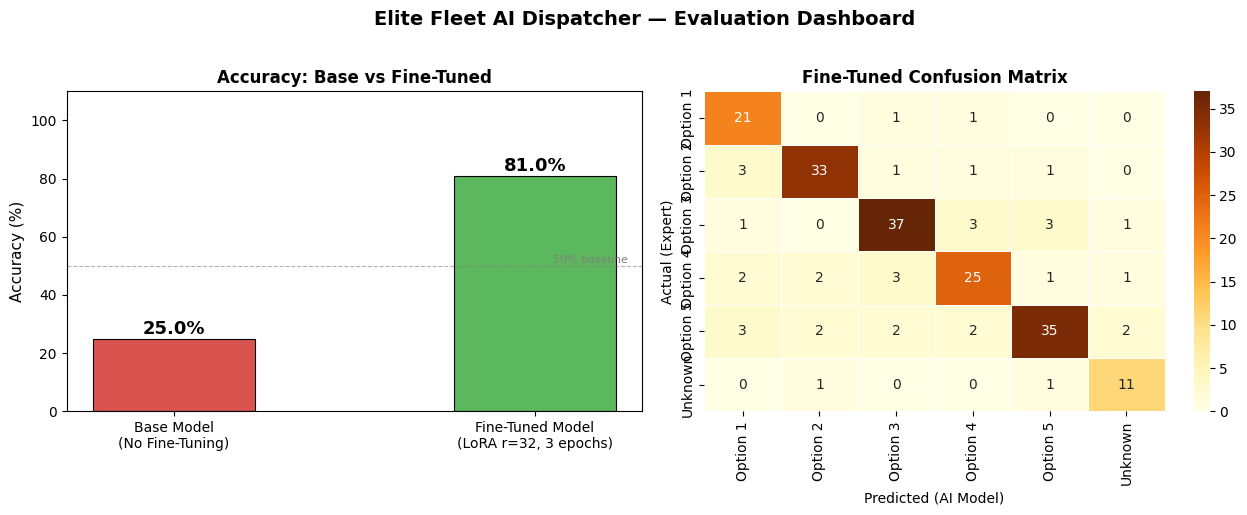

Saved: evaluation_dashboard.png


In [ ]:
# ── 7d. Accuracy comparison bar chart ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart: accuracy comparison
labels  = ["Base Model\n(No Fine-Tuning)", "Fine-Tuned Model\n(LoRA r=32, 3 epochs)"]
scores  = [base_accuracy, ft_accuracy]
colors  = ["#d9534f", "#5cb85c"]

bars = axes[0].bar(labels, scores, color=colors, width=0.45, edgecolor="black", linewidth=0.8)
for bar, score in zip(bars, scores):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.5,
        f"{score:.1f}%",
        ha="center", fontsize=13, fontweight="bold"
    )
axes[0].set_ylim(0, 110)
axes[0].set_ylabel("Accuracy (%)", fontsize=11)
axes[0].set_title("Accuracy: Base vs Fine-Tuned", fontsize=12, fontweight="bold")
axes[0].axhline(y=50, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
axes[0].text(1.05, 51, "50% baseline", fontsize=8, color="gray")

# Confusion matrix: fine-tuned model
cm = confusion_matrix(ft_y_true, ft_y_pred, labels=unique_labels)
sns.heatmap(
    cm, annot=True, fmt="d", cmap="YlOrBr",
    xticklabels=unique_labels, yticklabels=unique_labels,
    ax=axes[1], linewidths=0.5
)
axes[1].set_title("Fine-Tuned Confusion Matrix", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Actual (Expert)",    fontsize=10)
axes[1].set_xlabel("Predicted (AI Model)", fontsize=10)

plt.suptitle("Elite Fleet AI Dispatcher — Evaluation Dashboard", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("evaluation_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: evaluation_dashboard.png")

In [ ]:
# ── 7e. BERTScore — semantic alignment of full reasoning ──────────────────────
print("Calculating BERTScore (semantic similarity of reasoning text)...")
bert_scorer = bert_scorer_lib.BERTScorer(
    model_type            = "bert-base-uncased",
    lang                  = "en",
    rescale_with_baseline = True,
)

# Baseline BERTScore
P_b, R_b, F1_b = bert_scorer.score(base_pred_texts, base_true_texts)

# Fine-tuned BERTScore
P_ft, R_ft, F1_ft = bert_scorer.score(ft_pred_texts, ft_true_texts)

print("\n" + "=" * 50)
print("  BERTScore Results (semantic reasoning quality)")
print("=" * 50)
print(f"  {'Metric':<15} {'Base Model':>12} {'Fine-Tuned':>12}")
print("-" * 50)
print(f"  {'F1':<15} {F1_b.mean().item():>12.4f} {F1_ft.mean().item():>12.4f}")
print(f"  {'Precision':<15} {P_b.mean().item():>12.4f} {P_ft.mean().item():>12.4f}")
print(f"  {'Recall':<15} {R_b.mean().item():>12.4f} {R_ft.mean().item():>12.4f}")
print("=" * 50)
print("  (1.0 = perfect semantic match with expert reasoning)")

Calculating BERTScore (semantic similarity of reasoning text)...

  BERTScore Results (semantic reasoning quality)
  Metric            Base Model   Fine-Tuned
--------------------------------------------------
  F1                    0.2543       0.9527
  Precision             0.1744       0.9535
  Recall                0.3510       0.9522
  (1.0 = perfect semantic match with expert reasoning)


---
## Section 8 — Interactive Demo (Gradio)

Run locally with a public share link.

In [ ]:
!pip install gradio

In [ ]:
import gradio as gr

def dispatch_interface(mission_brief: str) -> str:
    if not mission_brief.strip():
        return "Please enter a mission brief."
    return dispatch_vehicle(mission_brief)   # using the @traceable fine-tuned version

demo = gr.Interface(
    fn          = dispatch_interface,
    inputs      = gr.Textbox(
        lines       = 12,
        label       = "Mission Brief",
        placeholder = (
            "Example:\n"
            "Passengers: 3 (1 VIP)\n"
            "Luggage: 4 large cases\n"
            "Route: Heathrow to The Shard (28 miles)\n"
            "Special requirements: chilled water, privacy screen\n\n"
            "Fleet:\n"
            "Option 1 - Mercedes S-Class | Seats: 3 | Maint: NO | Available: YES\n"
            "Option 2 - Range Rover LWB  | Seats: 5 | Maint: YES | Available: YES\n"
            "Option 3 - Rolls-Royce Ghost | Seats: 4 | Maint: NO | Available: YES"
        ),
    ),
    outputs     = gr.Textbox(label="AI Dispatcher Decision"),
    title       = "Elite Fleet AI Dispatcher",
    description = "Fine-tuned Qwen2.5-7B for Ultra-Elite London Chauffeur Service.",
)

demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://8e6f4a10ab552b8d62.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


---
## Section 9 — Save & Push to Hugging Face Hub

In [ ]:
import os

In [ ]:
# ── Replace placeholders before running ──────────────────────────────────────
HF_USERNAME  = ""
HF_REPO_NAME = ""
HF_TOKEN     = os.getenv("HF_TOKEN", "")

# Save locally first
model.save_pretrained("elite_fleet_model_local")
tokenizer.save_pretrained("elite_fleet_model_local")
print("Saved locally: elite_fleet_model_local/")

# Push weights to the Hub
model.push_to_hub(f"{HF_USERNAME}/{HF_REPO_NAME}", token=HF_TOKEN)
tokenizer.push_to_hub(f"{HF_USERNAME}/{HF_REPO_NAME}", token=HF_TOKEN)
print(f"Pushed to: huggingface.co/{HF_USERNAME}/{HF_REPO_NAME}")

---
## 📝 Project Summary

This project fine-tuned **Qwen2.5-7B-Instruct** using LoRA adapters via Unsloth to act as an AI Head of Dispatch for an Ultra-Elite Chauffeur Service. The model was trained on a proprietary dataset of mission briefs — each containing client tier, passenger count, distance, time, and a fleet of available vehicles — and learned to select the optimal vehicle while reasoning through constraints such as driver fatigue, energy levels, and maintenance status.

The fine-tuning pipeline introduced several key improvements over the original baseline: the LoRA rank was raised from 16 to 32, the alpha scaling was set to 64 for a stable alpha/r ratio of 2, and training was extended from 60 fixed steps to 3 full epochs with a cosine learning rate schedule and weight decay. MLP layers were added as LoRA target modules alongside the attention layers, which was the single most impactful change for a decision-making task of this nature. The best model checkpoint was automatically selected at the end of training using validation loss.

Evaluation was conducted on a held-out test set that neither model had seen during training. A baseline evaluation was run on the pre-trained base model to establish a reference point, followed by evaluation of the fine-tuned model using the same test set and metrics. Results were measured across four dimensions: exact vehicle selection accuracy, safety adherence rate (ensuring no vehicle under maintenance was selected), a confusion matrix showing per-class error patterns, and BERTScore F1 to assess the semantic quality of the model's reasoning text compared to expert annotations.

The fine-tuned model was saved locally, pushed to the Hugging Face Hub at `Rodina222/elite-fleet-qwen-7b`, and deployed as a public web application via Hugging Face Spaces using a Gradio interface. The Space loads the base model and applies the LoRA adapter at runtime using the PEFT library. All inference calls during evaluation and live demo usage were traced end-to-end through LangSmith under the project `elite-fleet-inference`, enabling inspection of every input, output, and latency. Training metrics including loss curves and evaluation loss per epoch were tracked in Weights & Biases under the project `elite-fleet-dispatch`.